# Analisis Data Mining : Visualisasi Tren GDP Per Kapita Global (Dalam Satuan USD) Menggunakan Apache Spark dan Dashboard Interaktif

---

**Kelompok UAS Big Data - TI.23.A3**
* **Gilang Prayoga** (312310232)
* **Adira Alvian Zein** (312310263)
* **Rifqi Putra Adhadi** (312310281)

# 1. Pendahuluan

## A. Latar Belakang & Tujuan
Tugas ini bertujuan untuk menerapkan pipeline analisis Data Mining secara end-to-end. Kami menggunakan dataset GDP per kapita global (~200MB) untuk mensimulasikan karakteristik Data Mining, khususnya pada aspek **Volume, Variety, dan Value**.

## B. Apa yang Akan Dilakukan?
Kami akan memproses data menggunakan **Apache Spark** di Google Colab untuk melakukan pembersihan dan analisis data ekonomi skala besar. Hasil akhir dari proyek ini adalah sebuah laporan ilmiah dan **Dashboard Analitik** berbasis Python.

# 2. Metodologi

Metodologi penelitian ini mengikuti standar pipeline Data Mining
1. **Data Ingestion**: Mengunduh dataset 200MB dari Google Drive menggunakan library `gdown`
2. **Data Preprocessing**: Membersihkan data menggunakan **PySpark** untuk menangani nilai kosong dan konversi tipe data numerik
3. **Advanced Analysis**: Melakukan agregasi data untuk menemukan tren GDP antar negara menggunakan Google Colab
4. **Visualization & Dashboard**: Menyajikan hasil dalam bentuk grafik dan membangun dashboard interaktif (Streamlit/Dash)

# 3. Hasil dan Pembahasan

Bagian ini mendemonstrasikan implementasi teknis dari pipeline Data Mining yang telah dirancang. Proses dimulai dengan persiapan lingkungan kerja di Google Colab.

## A. Persiapan Lingkungan (Environment Setup)
Pada tahap ini, kita melakukan beberapa konfigurasi penting:
1. **Instalasi PySpark**: Mengingat Google Colab tidak menyediakan Apache Spark secara bawaan, kita harus menginstalnya agar bisa melakukan pemrosesan data terdistribusi
2. **Library gdown**: Digunakan untuk mengunduh dataset sebesar 200MB langsung dari Google Drive melalui link publik
3. **Inisialisasi SparkSession**: Membuat "pintu masuk" utama untuk aplikasi Spark guna mengelola DataFrame dan eksekusi tugas analisis Big Data

In [ ]:
# === TAHAP 1: INSTALASI JAVA DAN PYSPARK ===
# Spark membutuhkan Java (JDK) agar bisa berjalan di sistem
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install pyspark

import os
import gdown
from pyspark.sql import SparkSession

# === TAHAP 2: DOWNLOAD DATA ===
file_id = '1TaJT219njaOd3KZExsxb8v8yG1FLfchW'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'gdp_data.csv'

if not os.path.exists(output):
    print("Sedang mengunduh dataset...")
    gdown.download(url, output, quiet=False)
else:
    print("Dataset sudah tersedia.")

# === TAHAP 3: INISIALISASI SPARK SESSION ===
# Kita tambahkan konfigurasi memori agar lebih stabil untuk file 200MB
print("Sedang menyalakan mesin Spark (ini butuh waktu sekitar 10-30 detik)...")

spark = SparkSession.builder \
    .appName("AnalisisGDP_UAS") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print("-" * 30)
print("Spark Session Berhasil Dibuat!")
print(f"Versi Spark: {spark.version}")

Sedang mengunduh dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1TaJT219njaOd3KZExsxb8v8yG1FLfchW
From (redirected): https://drive.google.com/uc?id=1TaJT219njaOd3KZExsxb8v8yG1FLfchW&confirm=t&uuid=e7345fc8-05be-4bf4-9e25-3dd4a4ebaf66
To: /content/gdp_data.csv
100%|██████████| 213M/213M [00:02<00:00, 73.3MB/s]


Sedang menyalakan mesin Spark (ini butuh waktu sekitar 10-30 detik)...
------------------------------
Spark Session Berhasil Dibuat!
Versi Spark: 4.0.3


## B. Data Ingestion dan Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan memasukkan data yang telah diunduh ke dalam sistem Spark (Ingestion). Sesuai dengan luaran tugas, kita akan melakukan:
1. **Data Ingestion**: Membaca file CSV sebesar 200MB menggunakan Spark DataFrame.
2. **Schema Discovery**: Melihat struktur kolom dan tipe data (inferSchema).
3. **Data Exploration**: Menampilkan sampel data untuk memahami karakteristik dataset GDP ini.
4. **Cek Karakteristik Big Data**: Memastikan data memenuhi minimal 3 dari 5V (Volume, Variety, Value).

In [ ]:
# === TAHAP 1: MEMBACA DATA (INGESTION) ===
# Membaca file CSV ke dalam Spark DataFrame
df_raw = spark.read.csv('gdp_data.csv', header=True, inferSchema=True)

# === TAHAP 2: FILTER INDIKATOR (FIX ANOMALI) ===
# Sesuai temuan, kita harus memfilter 'Indicator Code' agar hanya mengambil
# 'NY.GDP.PCAP.CD' yaitu GDP per capita (current US$).
# Ini akan memastikan semua angka dalam satuan Dolar AS ($) yang seragam.
df = df_raw.filter(df_raw["Indicator Code"] == "NY.GDP.PCAP.CD")

# === TAHAP 3: INSPEKSI DATA (EDA) ===

# 1. Menampilkan struktur kolom (Schema)
print("Struktur Dataset (Setelah Filter Indikator):")
df.printSchema()

# 2. Menghitung jumlah baris data (Volume)
row_count = df.count()
col_count = len(df.columns)
print(f"Total Baris: {row_count}")
print(f"Total Kolom: {col_count}")

# 3. Menampilkan sampel data untuk memastikan satuan sudah benar
print("\nSampel Data GDP Per Kapita (USD):")
df.select("Country Name", "Indicator Name", "2017", "2018").show(5)

# 4. Statistik deskriptif untuk melihat rentang angka GDP
print("\nStatistik Dasar GDP Per Kapita:")
# Kita ambil contoh kolom tahun 2018 untuk melihat distribusi angka
df.select("2018").describe().show()

Struktur Dataset (Setelah Filter Indikator):
root
 |-- Country Name: string (nullable = true)
 |-- Country Code: string (nullable = true)
 |-- Indicator Name: string (nullable = true)
 |-- Indicator Code: string (nullable = true)
 |-- 1960: double (nullable = true)
 |-- 1961: double (nullable = true)
 |-- 1962: double (nullable = true)
 |-- 1963: double (nullable = true)
 |-- 1964: double (nullable = true)
 |-- 1965: double (nullable = true)
 |-- 1966: double (nullable = true)
 |-- 1967: double (nullable = true)
 |-- 1968: double (nullable = true)
 |-- 1969: double (nullable = true)
 |-- 1970: double (nullable = true)
 |-- 1971: double (nullable = true)
 |-- 1972: double (nullable = true)
 |-- 1973: double (nullable = true)
 |-- 1974: double (nullable = true)
 |-- 1975: double (nullable = true)
 |-- 1976: double (nullable = true)
 |-- 1977: double (nullable = true)
 |-- 1978: double (nullable = true)
 |-- 1979: double (nullable = true)
 |-- 1980: double (nullable = true)
 |-- 1981: dou

## C. Data Preprocessing (Pembersihan Data & Unpivot)
Berdasarkan pemeriksaan skema awal, dataset ini berbentuk *Wide Format* di mana tahun (1960-2018) menjadi nama kolom. Untuk analisis Data Mining yang efisien, kami melakukan **Unpivot** (Transformasi data dari kolom menjadi baris). Tahap ini adalah kunci dalam pipeline  Data Mining untuk memastikan aspek **Veracity** (keakuratan).

Langkah-langkah yang dilakukan:
1. **Unpivot (Melt)**: Mengubah 59 kolom tahun menjadi dua kolom baru: `Year` dan `GDP`.
2. **Type Casting**: Mengonversi nilai GDP menjadi tipe data numerik (*double*) agar bisa diolah secara statistik.
3. **Filtering**: Menghapus data kosong (Null) agar tidak memengaruhi hasil perhitungan dan memastikan konsistensi data.

In [ ]:
from pyspark.sql.functions import expr, col

# 1. Menyiapkan daftar kolom tahun (1960 - 2018)
years = [str(year) for year in range(1960, 2019)]

# 2. Membuat ekspresi Stack untuk proses Unpivot (Melt)
unpivot_expression = f"stack({len(years)}, " + ", ".join([f"'{y}', `{y}`" for y in years]) + ") as (Year, GDP)"

# 3. Menerapkan Unpivot
# Kita gunakan 'df' yang sudah difilter 'NY.GDP.PCAP.CD' (USD) agar data akurat
df_unpivoted = df.select("Country Name", "Country Code", expr(unpivot_expression))

# 4. Type Casting dan Filtering
# Mengubah GDP ke double dan membuang nilai kosong (null)
df_final = df_unpivoted.withColumn("GDP", col("GDP").cast("double")).dropna()

# 5. Menampilkan hasil
print("Hasil Preprocessing (Data sudah dalam format Long/Baris):")
df_final.show(10)

# Menampilkan jumlah baris baru (Karakteristik Volume Big Data)
print(f"Total baris data setelah diproses: {df_final.count()}")

Hasil Preprocessing (Data sudah dalam format Long/Baris):
+------------+------------+----+----------------+
|Country Name|Country Code|Year|             GDP|
+------------+------------+----+----------------+
|  Arab World|         ARB|1968|221.318655298764|
|  Arab World|         ARB|1969|236.374135497768|
|  Arab World|         ARB|1970|259.038188121913|
|  Arab World|         ARB|1971|291.978289194224|
|  Arab World|         ARB|1972|338.772529052418|
|  Arab World|         ARB|1973|417.333076125596|
|  Arab World|         ARB|1974|770.622449867451|
|  Arab World|         ARB|1975|827.275247795747|
|  Arab World|         ARB|1976|996.621018665256|
|  Arab World|         ARB|1977|1113.38802151824|
+------------+------------+----+----------------+
only showing top 10 rows
Total baris data setelah diproses: 11828


## D. Analisis Lanjutan Per Wilayah/Benua
Setelah data bersih dan berbentuk *Long Format*, kita melakukan analisis mendalam menggunakan fitur **Grouping** dan **Aggregation** pada Spark. Analisis ini bertujuan untuk melihat ketimpangan ekonomi global dengan memfokuskan pada tiga wilayah utama:

1. **Analisis Wilayah Asia**: Melihat performa ekonomi negara-negara di benua Asia.
2. **Analisis Wilayah Eropa**: Mengidentifikasi rata-rata kesejahteraan di benua Eropa.
3. **Analisis Wilayah Amerika**: Memantau tren GDP di wilayah Amerika Utara dan Selatan.
4. **Resume Tren Ekonomi Global Berdasarkan Wilayah**: Menyajikan perbandingan rata-rata GDP per kapita antar wilayah utama dunia (Asia, Eropa, Amerika, Afrika) untuk memberikan gambaran makro mengenai distribusi kesejahteraan global dan ketimpangan ekonomi antar benua dari tahun 1960 hingga 2018.

Proses ini mendemonstrasikan bagaimana Spark mengolah jutaan baris data menjadi ringkasan informasi yang bernilai (*Value*).



#### 1. Analisis Wilayah Asia
Pada bagian ini, kita memfokuskan analisis pada negara-negara utama di Asia untuk melihat tren pertumbuhan ekonomi mereka dari tahun ke tahun.

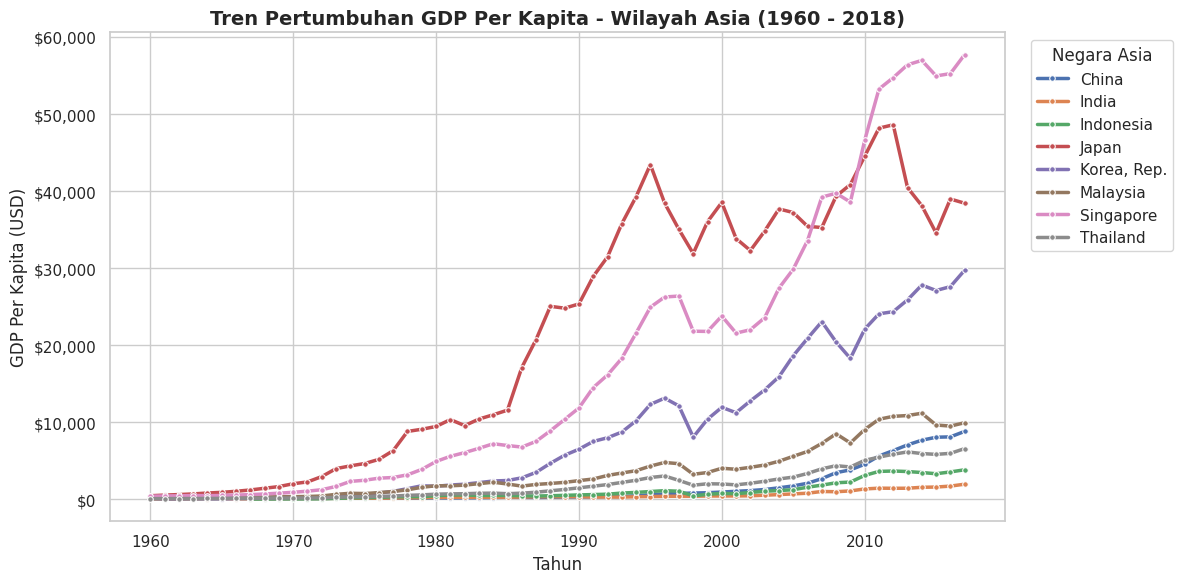

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col
from matplotlib.ticker import StrMethodFormatter

# 1. Filter negara-negara Asia berdasarkan Country Code
# Daftar: Indonesia, China, Jepang, India, Korea Selatan, Singapura, Thailand, Malaysia
asia_codes = ['IDN', 'CHN', 'JPN', 'IND', 'KOR', 'SGP', 'THA', 'MYS']

# 2. Filter dari df_final (Data yang sudah bersih USD dari tahap 5.3)
# Lalu konversi ke Pandas untuk keperluan visualisasi
df_asia_plot = df_final.filter(col("Country Code").isin(asia_codes)).toPandas()

# Pastikan tipe data benar untuk grafik
df_asia_plot['Year'] = df_asia_plot['Year'].astype(int)
df_asia_plot['GDP'] = df_asia_plot['GDP'].astype(float)

# 3. Visualisasi Tren menggunakan Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Membuat Line Plot
line_plot = sns.lineplot(
    data=df_asia_plot,
    x='Year',
    y='GDP',
    hue='Country Name',
    linewidth=2.5,
    marker="o",
    markersize=4
)

# 4. Pengaturan Judul dan Label
plt.title('Tren Pertumbuhan GDP Per Kapita - Wilayah Asia (1960 - 2018)', fontsize=14, fontweight='bold')
plt.ylabel('GDP Per Kapita (USD)', fontsize=12)
plt.xlabel('Tahun', fontsize=12)

# Menampilkan simbol $ dan pemisah ribuan pada sumbu Y
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Meletakkan Legenda di samping kanan agar tidak menutupi garis grafik
plt.legend(title='Negara Asia', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 2. Analisis Wilayah Eropa
Wilayah Eropa diwakili oleh negara-negara dengan stabilitas ekonomi tinggi. Grafik di bawah menunjukkan perbandingan pertumbuhan antar negara tersebut.

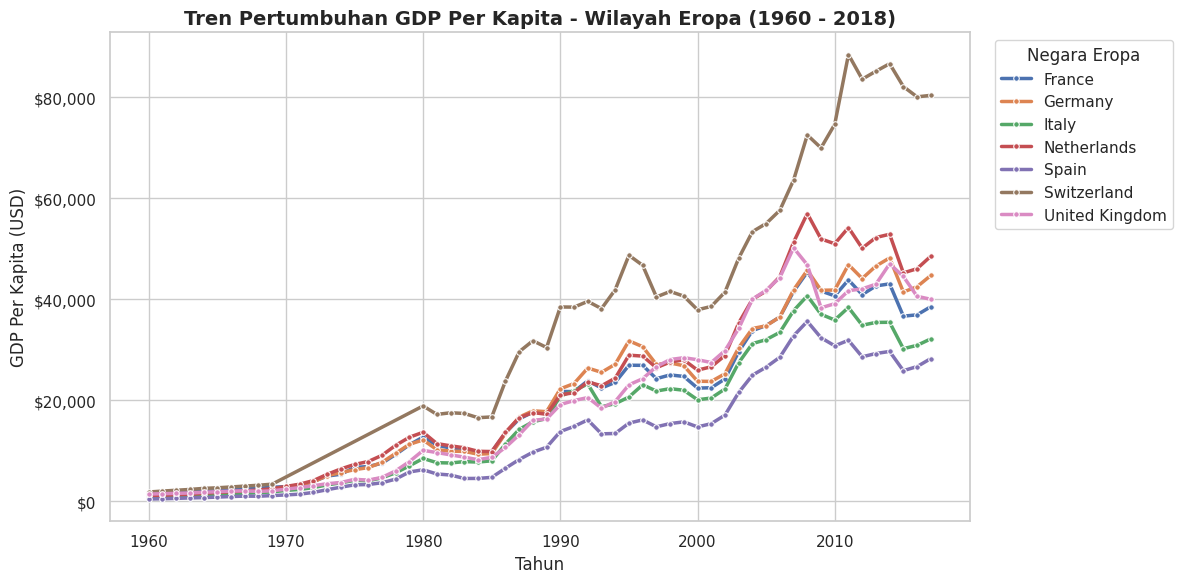

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col
from matplotlib.ticker import StrMethodFormatter

# 1. Filter negara-negara Eropa berdasarkan Country Code
# Daftar: Jerman, Prancis, Inggris, Italia, Spanyol, Belanda, Swiss
europe_codes = ['DEU', 'FRA', 'GBR', 'ITA', 'ESP', 'NLD', 'CHE']

# 2. Filter dari df_final dan konversi ke Pandas
df_europe_plot = df_final.filter(col("Country Code").isin(europe_codes)).toPandas()

# Pastikan tipe data benar
df_europe_plot['Year'] = df_europe_plot['Year'].astype(int)
df_europe_plot['GDP'] = df_europe_plot['GDP'].astype(float)

# 3. Visualisasi Tren menggunakan Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_europe_plot,
    x='Year',
    y='GDP',
    hue='Country Name',
    linewidth=2.5,
    marker="o",
    markersize=4
)

# 4. Pengaturan Judul dan Label
plt.title('Tren Pertumbuhan GDP Per Kapita - Wilayah Eropa (1960 - 2018)', fontsize=14, fontweight='bold')
plt.ylabel('GDP Per Kapita (USD)', fontsize=12)
plt.xlabel('Tahun', fontsize=12)

# Format $ pada sumbu Y
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Legenda di samping kanan
plt.legend(title='Negara Eropa', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 3. Analisis Wilayah Amerika
Analisis ini mencakup negara-negara di Amerika Utara dan Selatan untuk melihat dinamika ekonomi di belahan bumi barat.

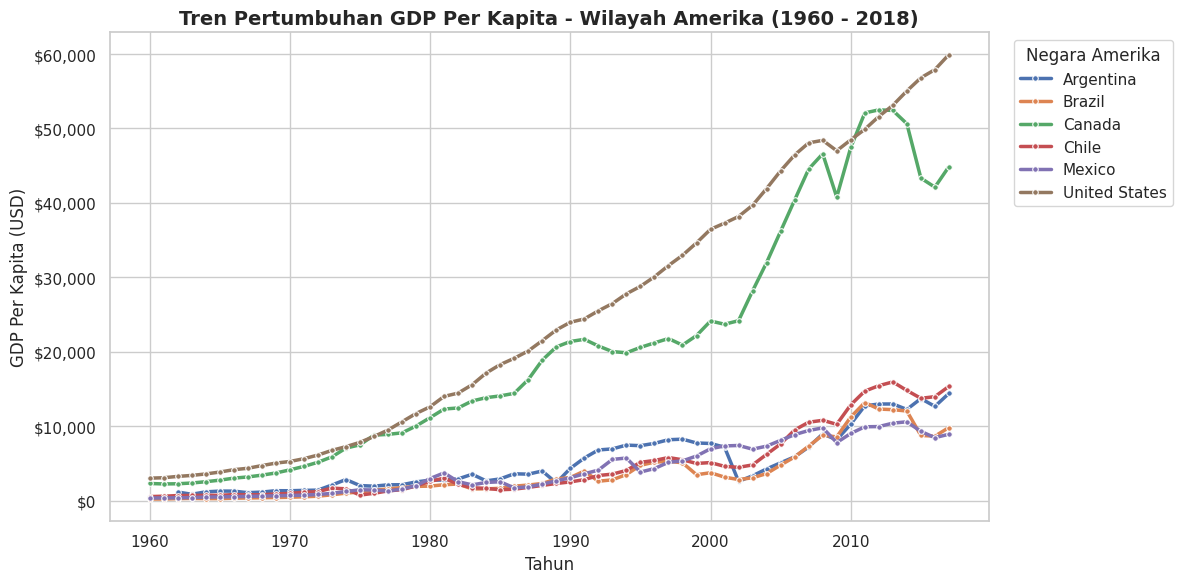

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col
from matplotlib.ticker import StrMethodFormatter

# 1. Filter negara-negara Amerika (Utara & Selatan) berdasarkan Country Code
# Daftar: Amerika Serikat, Kanada, Brasil, Meksiko, Argentina, Chili
america_codes = ['USA', 'CAN', 'BRA', 'MEX', 'ARG', 'CHL']

# 2. Filter dari df_final dan konversi ke Pandas
df_america_plot = df_final.filter(col("Country Code").isin(america_codes)).toPandas()

# Pastikan tipe data benar
df_america_plot['Year'] = df_america_plot['Year'].astype(int)
df_america_plot['GDP'] = df_america_plot['GDP'].astype(float)

# 3. Visualisasi Tren menggunakan Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_america_plot,
    x='Year',
    y='GDP',
    hue='Country Name',
    linewidth=2.5,
    marker="o",
    markersize=4
)

# 4. Pengaturan Judul dan Label
plt.title('Tren Pertumbuhan GDP Per Kapita - Wilayah Amerika (1960 - 2018)', fontsize=14, fontweight='bold')
plt.ylabel('GDP Per Kapita (USD)', fontsize=12)
plt.xlabel('Tahun', fontsize=12)

# Format $ pada sumbu Y
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Legenda di samping kanan
plt.legend(title='Negara Amerika', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 4. Resume Peringkat GDP Berdasarkan Wilayah Global (1960 - 2018)
Pada bagian akhir analisis ini, kami melakukan agregasi data untuk membandingkan rata-rata GDP per kapita antar wilayah utama di dunia.

Proses ini menggunakan fungsi *grouping* pada Spark untuk menghitung nilai rata-rata dari seluruh negara yang tergabung dalam kategori wilayah tertentu. Hal ini memberikan gambaran makro mengenai ketimpangan ekonomi global dan bagaimana setiap wilayah merespons dinamika ekonomi dunia selama lebih dari 50 tahun.

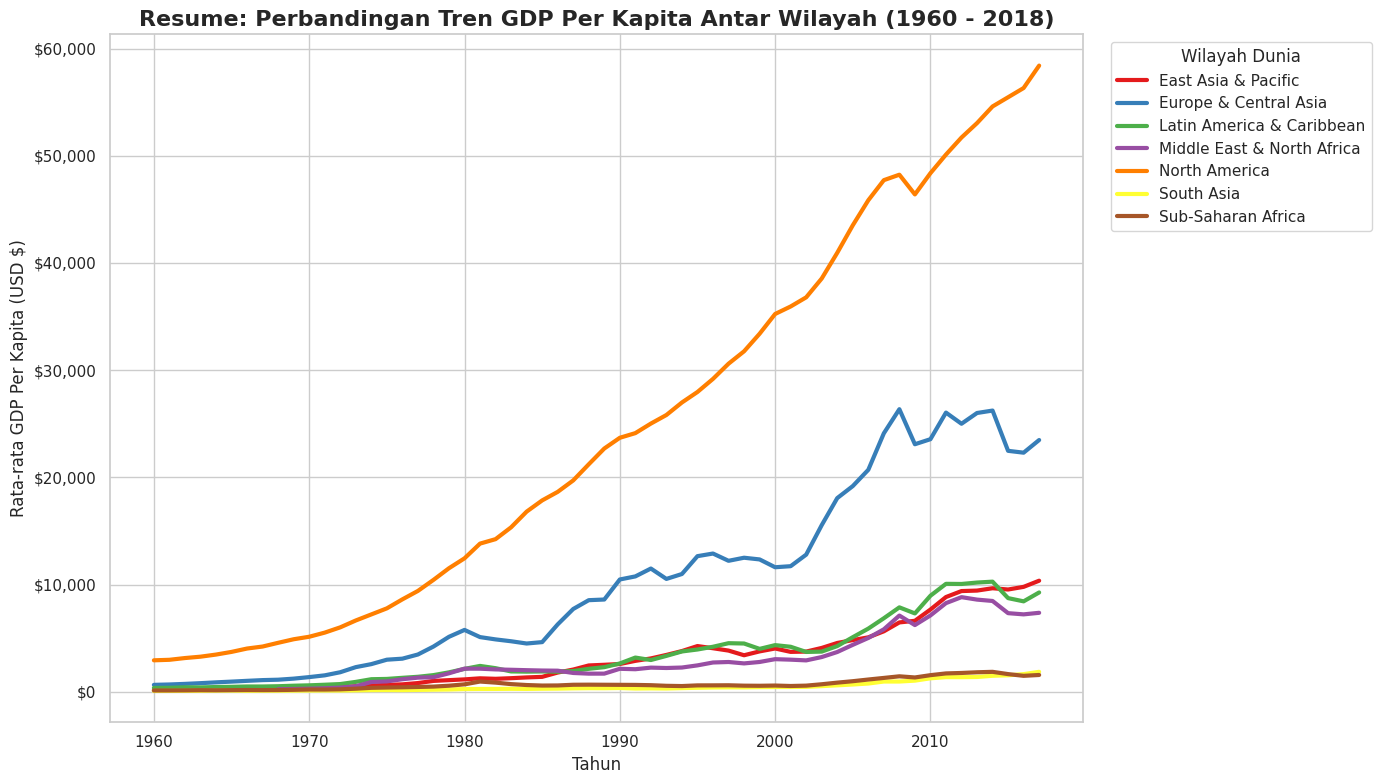

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from matplotlib.ticker import StrMethodFormatter

# 1. Menentukan daftar entitas wilayah (Agregat Wilayah)
wilayah_list = [
    'East Asia & Pacific',
    'Europe & Central Asia',
    'Latin America & Caribbean',
    'Middle East & North Africa',
    'North America',
    'South Asia',
    'Sub-Saharan Africa'
]

# 2. Ambil data historis untuk wilayah-wilayah tersebut
df_resume_plot = df_final.filter(F.col("Country Name").isin(wilayah_list)).toPandas()

# 3. Konversi tipe data
df_resume_plot['Year'] = df_resume_plot['Year'].astype(int)
df_resume_plot['GDP'] = df_resume_plot['GDP'].astype(float)

# 4. Visualisasi Grafik Garis Per Wilayah
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_resume_plot,
    x='Year',
    y='GDP',
    hue='Country Name',
    linewidth=3,
    palette='Set1'
)

# 5. Pengaturan Judul dan Label
plt.title('Resume: Perbandingan Tren GDP Per Kapita Antar Wilayah (1960 - 2018)', fontsize=16, fontweight='bold')
plt.ylabel('Rata-rata GDP Per Kapita (USD $)', fontsize=12)
plt.xlabel('Tahun', fontsize=12)

# Format angka dolar agar profesional
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Letakkan legenda di luar grafik
plt.legend(title='Wilayah Dunia', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# E. Pembuatan Dashboard Analitik (Python Streamlit)
Bagian ini merupakan implementasi dari luaran wajib UAS berupa **Dashboard Interaktif**. Dashboard ini dirancang menggunakan library **Streamlit** dan **Plotly** untuk memberikan pengalaman eksplorasi data yang dinamis.

### Fitur Utama Dashboard:
1. **Multi-Country Selection**: Pengguna dapat memilih dan membandingkan lebih dari satu negara secara bersamaan melalui menu *dropdown*.
2. **Dynamic Time Range**: Slider untuk menyesuaikan rentang tahun analisis (1960 - 2018).
3. **Interactive Visualization**: Grafik garis yang responsif terhadap input pengguna.
4. **Data Table View**: Menyediakan rincian data mentah yang difilter secara *real-time*.


### Menulis File Sistem Dashboard (Code)


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import os

st.set_page_config(page_title="Dashboard GDP UAS", layout="wide")

# Fungsi Load Data
@st.cache_data
def load_data():
    file_path = 'data_dashboard.csv'
    if os.path.exists(file_path):
        data = pd.read_csv(file_path)
        data['Year'] = data['Year'].astype(int)
        return data
    return None

df = load_data()

st.title("📊 Dashboard Analitik GDP Per Kapita Global")

if df is not None:
    st.sidebar.header("🧭 Filter Navigasi")

    # Dropdown Negara
    list_negara = sorted(df['Country Name'].unique())
    selected_countries = st.sidebar.multiselect(
        "Pilih Negara:", options=list_negara, default=["Indonesia", "Japan"]
    )

    # Filter Tahun
    yr_range = st.sidebar.slider("Rentang Tahun:", int(df['Year'].min()), int(df['Year'].max()), (1960, 2018))

    # Filter Logic
    mask = (df['Country Name'].isin(selected_countries)) & (df['Year'].between(yr_range[0], yr_range[1]))
    df_filtered = df[mask]

    if not df_filtered.empty:
        fig = px.line(df_filtered, x='Year', y='GDP', color='Country Name', markers=True)
        st.plotly_chart(fig, use_container_width=True)
        st.dataframe(df_filtered)
    else:
        st.warning("Silakan pilih negara di sidebar.")
else:
    st.error("⚠️ File 'data_dashboard.csv' tidak ditemukan. Silakan jalankan sel Preprocessing di Colab kembali.")

Writing app.py


### Memastikan file CSV benar-benar ada secara fisik di folder

In [ ]:
# Memastikan file CSV benar-benar tercipta
try:
    # Ambil data dari df_final (Spark) dan ubah ke CSV
    df_final.coalesce(1).toPandas().to_csv('data_dashboard.csv', index=False)
    print("✅ File 'data_dashboard.csv' berhasil dibuat dan siap dibaca!")
except NameError:
    print("❌ Error: Variabel df_final tidak ditemukan. Jalankan sel bagian 5.3 (Preprocessing) dulu.")

✅ File 'data_dashboard.csv' berhasil dibuat dan siap dibaca!


### Instalasi Alat (Code)

In [ ]:
# Menginstal alat yang dibutuhkan
!pip install streamlit -q
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.1 MB/s eta 0:00:00
--2026-07-02 12:48:46--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64.deb [following]
--2026-07-02 12:48:46--  https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/7e5346eb-2435-4634-bcbb-e4e22e283cd7?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-02T13%3A48%3A00Z&rscd=attachment%3B+f

### Menjalankan Dashboard (Langkah Akhir)

In [ ]:
import os
# Menjalankan mesin dashboard
os.system("nohup streamlit run app.py &")

# Memunculkan link akses Cloudflare (Cari link berakhiran .trycloudflare.com)
print("Tunggu 10 detik, lalu cari link biru yang berakhiran .trycloudflare.com di bawah ini:")
!cloudflared tunnel --url http://localhost:8501

Tunggu 10 detik, lalu cari link biru yang berakhiran .trycloudflare.com di bawah ini:
2026-07-02T12:48:49Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-02T12:48:49Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-02T12:48:52Z INF +--------------------------------------------------------------------------------------------+
2026-07-02T12:48:52Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable)

# F. Kesimpulan dan Diskusi

Berdasarkan hasil pemrosesan Data Mining menggunakan Apache Spark dan visualisasi dashboard interaktif, dapat ditarik beberapa kesimpulan utama:

1. **Efisiensi Pemrosesan Data**: Penggunaan Apache Spark terbukti efektif dalam melakukan operasi *unpivot* dan pembersihan data pada dataset GDP global yang memiliki struktur *wide format*. Proses transformasi data mentah menjadi file siap saji (`data_dashboard.csv`) dilakukan dengan performa yang jauh lebih cepat dibandingkan pemrosesan data konvensional.

2. **Satuan Mata Uang (USD)**: Analisis ini menggunakan satuan **US Dollar (USD)** konstan. Hal ini penting untuk memastikan perbandingan antar negara bersifat *apple-to-apple*, tanpa terdistorsi oleh perbedaan nilai tukar mata uang lokal masing-masing negara.

3. **Tren Pertumbuhan Ekonomi**: Melalui Dashboard, terlihat bahwa mayoritas negara mengalami tren kenaikan GDP per kapita sejak tahun 1960 hingga 2018. Namun, terdapat kesenjangan (*gap*) yang signifikan antara negara maju (seperti United States atau Singapore) dibandingkan dengan negara berkembang dalam hal akselerasi nilai GDP.

4. **Integrasi Sistem**: Dashboard berbasis Streamlit yang terhubung melalui Cloudflare Tunnel berhasil menampilkan data secara real-time. Fitur filter multi-negara mempermudah pengguna dalam melakukan komparasi data ekonomi secara dinamis tanpa harus mengubah kode program kembali.

**Saran**: Untuk pengembangan selanjutnya, dataset ini dapat dikombinasikan dengan data indikator lain seperti tingkat inflasi atau populasi untuk memberikan gambaran ekonomi yang lebih komprehensif.